## Initial Data Exploration

In this part we will do the basic data analysis, which is cleaning the dataset, focusing on missingness first.

### Changes per column

**Composition (wt%)**
- **C, Si, Mn:** Unchanged, no missing values.
- **S:** The 7 `"<0.002"` values are set to the column minimum (0.001). The 4 missing values are imputed with the median.
- **P:** The 10 missing values are imputed with the median.
- **Ni, Cr:** Missing values are imputed with 0.
- **Mo, V:** `"<x"` values are set to the column minimum (0). Missing values are imputed with 0.
- **Cu:** `"<0.01"` values are set to the column minimum, then the column is dropped (1074 missing values).
- **Co, W:** `"<x"` values are set to the column minimum, then the columns are dropped (92% and 95% missing).

**Composition (ppm)**
- **O_ppm:** Missing values are imputed with the median.
- **Ti_ppm, Nb_ppm:** `"<x"` values are set to half the limit, rounded down. Missing values are imputed with 0.
- **Al_ppm:** `"<x"` values are set to half the limit, rounded down. Missing values are imputed with the median.
- **N_ppm:** `"67tot33res"` style values are replaced by the total nitrogen (67). Missing values are imputed with the median.
- **B_ppm:** `"<x"` values are set to half the limit, then the column is dropped (1135 missing values).
- **Sn_ppm, As_ppm, Sb_ppm:** `"<x"` values are set to half the limit, then the columns are dropped (82% to 86% missing).

**Welding parameters**
- **current_A, voltage_V:** Missing values are imputed with the median per weld type.
- **AC_DC:** Encoded as DC = 1, AC = 0. The 59 missing rows with a + polarity are set to DC. The remaining 156 are filled with the mode and flagged in `AC_DC_unknown`.
- **electrode_polarity:** Encoded as + = 1, - = -1, 0 = 0 (AC). The 4 AC rows marked + are corrected to 0. The 156 missing rows are filled with the mode.
- **heat_input_kJ_mm:** Unchanged, no missing values.
- **interpass_temp_C:** The range `"150-200"` is replaced by 175.
- **weld_type:** ShMA merged into MMA, NGSAW into SA, NGGMA into GMAA, then one-hot encoded into 7 `weld_type_` columns.
- **pwht_temp_C, pwht_time_h:** The 13 rows with missing values are dropped.

**Targets**
- **yield_strength_MPa, uts_MPa, elongation_pct, reduction_area_pct, charpy_toughness_J, charpy_temp_C:** Not imputed.
- **hardness_kg_mm2, fatt50_C:** Dropped (more than 1000 missing values).

**Microstructure**
- **primary_ferrite_pct:** `"<1"` values are set to the column minimum, then the column is dropped with the four other microstructure columns (more than 1000 missing values each).

**Other**
- **weld_id:** Kept, it is needed later to group rows by source for cross-validation.
- **AC_DC_unknown:** New column, 1 where the current type and polarity were not reported.

### What we did (sumary by Claude given the file):

1. Load the raw file, replace `N` by a missing value.
2. List every value that prevents a numerical column from being converted to a float.
3. Describe the affected columns to choose an imputation.
4. Replace the `"<x"` detection-limit values: minimum for the wt% columns, half the limit for the ppm columns.
5. Convert every clean numerical column to float.
6. Look at the number of unique values and the distribution of the categorical columns.
7. Encode AC_DC, electrode_polarity and weld_type.
8. Impute AC_DC and electrode_polarity.
9. Drop Sn_ppm, As_ppm, Sb_ppm, Co, W and the 13 rows without post weld heat treatment.
10. Replace the `interpass_temp_C` range by its middle value.
11. Drop every column with more than 1000 missing values.
12. Impute the remaining missing values of the input columns.
13. Drop the duplicate flag and save to `../data/welddb_cleaned_missing.csv`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

Display options so that tables are printed in full, without columns or rows being hidden.

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [7]:
columns = [
    "C", "Si", "Mn", "S", "P", "Ni", "Cr", "Mo", "V", "Cu", "Co", "W",
    "O_ppm", "Ti_ppm", "N_ppm", "Al_ppm", "B_ppm", "Nb_ppm", "Sn_ppm", "As_ppm", "Sb_ppm",
    "current_A", "voltage_V", "AC_DC", "electrode_polarity",
    "heat_input_kJ_mm", "interpass_temp_C", "weld_type",
    "pwht_temp_C", "pwht_time_h",
    "yield_strength_MPa", "uts_MPa", "elongation_pct", "reduction_area_pct",
    "charpy_temp_C", "charpy_toughness_J", "hardness_kg_mm2", "fatt50_C",
    "primary_ferrite_pct", "ferrite_2nd_phase_pct", "acicular_ferrite_pct",
    "martensite_pct", "ferrite_carbide_pct",
    "weld_id",
]

print(len(columns))
assert len(columns) == 44

df = pd.read_csv("../data/raw/welddb.data", sep=r"\s+", header=None, names=columns)

print(df.shape)
assert df.shape[1] == 44

df.to_csv("../data/welddb.csv", index=False)

44
(1652, 44)


The raw file `welddb.data` is not a CSV. The column names and their order are taken from `welddb.info`.

- Not specifying a separator loads everything into a single column, of size (1652, 1).
- Using a single space as separator raises an error, as some rows contain double whitespace.
- We therefore separate on any whitespace, with `sep=r"\s+"`.

In [8]:
df = df.replace("N", pd.NA)

In the raw file, `N` means the value was not reported (`welddb.info`). It is replaced by a proper missing value so that pandas recognises it.

In [9]:
df.head(10)

,C,Si,Mn,S,P,Ni,Cr,Mo,V,Cu,Co,W,O_ppm,Ti_ppm,N_ppm,Al_ppm,B_ppm,Nb_ppm,Sn_ppm,As_ppm,Sb_ppm,current_A,voltage_V,AC_DC,electrode_polarity,heat_input_kJ_mm,interpass_temp_C,weld_type,pwht_temp_C,pwht_time_h,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct,charpy_temp_C,charpy_toughness_J,hardness_kg_mm2,fatt50_C,primary_ferrite_pct,ferrite_2nd_phase_pct,acicular_ferrite_pct,martensite_pct,ferrite_carbide_pct,weld_id
0,0.037,0.30,0.65,0.008,0.012,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,250,14,392,466,31.9,80.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,0,0,NaN,NaN,NaN,NaN,-28,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,580,2,370,456,35.2,80.6,-38,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,250,14,413,498,31.2,80.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,0,0,NaN,NaN,NaN,NaN,-48,100,NaN,NaN,32,28,40,0,0,Evans-Ni/CMn-1990/1991-0Bawch
5,0.037,0.31,1.03,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,580,2,402,490,31.0,80.6,-44,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Bht
6,0.044,0.35,1.43,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,250,14,468,551,29.4,78.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Caw
7,0.044,0.35,1.43,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,0,0,NaN,NaN,NaN,NaN,-53,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Cawch
8,0.044,0.35,1.43,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,580,2,436,529,31.6,78.8,-58,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Cht
9,0.045,0.33,1.85,0.007,0.016,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1.0,200,MMA,250,14,514,588,28.0,76.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Daw


In [10]:
print(df.dtypes)
print(df.isna().sum())

C                        float64
Si                       float64
Mn                       float64
S                            str
P                            str
Ni                           str
Cr                           str
Mo                           str
V                            str
Cu                           str
Co                           str
W                            str
O_ppm                        str
Ti_ppm                       str
N_ppm                        str
Al_ppm                       str
B_ppm                        str
Nb_ppm                       str
Sn_ppm                       str
As_ppm                       str
Sb_ppm                       str
current_A                    str
voltage_V                    str
AC_DC                        str
electrode_polarity           str
heat_input_kJ_mm         float64
interpass_temp_C             str
weld_type                    str
pwht_temp_C                  str
pwht_time_h                  str
yield_stre

Most columns are read as strings although they should be numerical, which means they contain values that cannot be converted to a float.

In [11]:
non_numeric_cols = ["AC_DC", "electrode_polarity", "weld_type", "weld_id"]
numeric_intended_cols = [c for c in columns if c not in non_numeric_cols]

bad_values = []
for col in numeric_intended_cols:
    coerced = pd.to_numeric(df[col], errors="coerce")
    mask = df[col].notna() & coerced.isna()
    for val, count in df.loc[mask, col].value_counts().items():
        bad_values.append((col, val, count))

bad_values_df = pd.DataFrame(bad_values, columns=["column", "value", "count"])
bad_values_df

,column,value,count
0,S,<0.002,7
1,Mo,<0.01,2
2,V,<0.0005,266
3,V,<0.01,31
4,V,<5,9
5,V,<0.005,2
6,Cu,<0.01,14
7,Co,<0.01,21
8,W,<0.1,12
9,Ti_ppm,<100,50


Here we list every value that stops us from converting a column we know should be numerical into an actually numerical column, with its count.

In [12]:
error_cols = ["S", "Mo", "V", "Cu", "Co", "W", "Ti_ppm", "Al_ppm", "B_ppm", "Nb_ppm", "Sn_ppm", "As_ppm", "Sb_ppm", "interpass_temp_C", "primary_ferrite_pct"]
df[error_cols].apply(pd.to_numeric, errors="coerce").describe()

,S,Mo,V,Cu,Co,W,Ti_ppm,Al_ppm,B_ppm,Nb_ppm,Sn_ppm,As_ppm,Sb_ppm,interpass_temp_C,primary_ferrite_pct
count,1641.000000,791.000000,620.000000,564.000000,108.000000,63.000000,865.000000,502.000000,85.000000,453.000000,291.000000,226.000000,254.000000,1614.000000,96.000000
mean,0.009561,0.480358,0.072443,0.176188,0.082889,0.140794,81.268786,172.926454,20.658824,217.013245,41.795918,28.603832,28.144016,204.902726,19.552083
std,0.011239,0.477423,0.096364,0.325897,0.385763,0.496768,100.110707,155.781121,18.431051,263.347250,89.606313,41.712908,35.825789,39.550604,10.773134
min,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004000,1.000000,0.000000,0.000000,0.003000,0.000000,20.000000,0.000000
25%,0.006000,0.000000,0.004000,0.000000,0.000000,0.000000,30.000000,69.250000,7.000000,5.000000,0.008000,0.030000,0.008000,200.000000,13.750000
50%,0.007000,0.340000,0.015000,0.030000,0.000000,0.000000,41.000000,140.000000,17.000000,120.000000,40.000000,10.000000,10.000000,200.000000,19.000000
75%,0.010000,1.010000,0.180000,0.190000,0.010000,0.000000,110.000000,220.000000,26.000000,300.000000,60.000000,50.000000,50.000000,200.000000,24.000000
max,0.140000,1.500000,0.320000,1.630000,2.800000,2.990000,690.000000,680.000000,69.000000,1000.000000,1000.000000,200.000000,200.000000,300.000000,48.000000


We describe every column from `bad_values_df` except `hardness_kg_mm2` and `N_ppm`, whose errors need further cosideration. The scale of each column decides which kind of imputation makes more sense for the <x errors> `"<x"` values.

In [13]:
min_cols = ["S", "Mo", "V", "Cu", "Co", "W", "primary_ferrite_pct"]
half_limit_cols = ["Ti_ppm", "Al_ppm", "B_ppm", "Nb_ppm", "Sn_ppm", "As_ppm", "Sb_ppm"]

for col in min_cols:
    mask = df[col].notna() & df[col].astype(str).str.startswith("<")
    col_min = pd.to_numeric(df[col], errors="coerce").min()
    df.loc[mask, col] = str(col_min)
    df[col] = df[col].astype(float)

for col in half_limit_cols:
    mask = df[col].notna() & df[col].astype(str).str.startswith("<")
    df.loc[mask, col] = df.loc[mask, col].str[1:].astype(float).floordiv(2).astype(str)
    df[col] = df[col].astype(float)

df[min_cols + half_limit_cols].dtypes

S                      float64
Mo                     float64
V                      float64
Cu                     float64
Co                     float64
W                      float64
primary_ferrite_pct    float64
Ti_ppm                 float64
Al_ppm                 float64
B_ppm                  float64
Nb_ppm                 float64
Sn_ppm                 float64
As_ppm                 float64
Sb_ppm                 float64
dtype: object

- **S, Mo, V, Cu, Co, W, primary_ferrite_pct:** Min imputation, the `"<x"` value is replaced by the smallest real value of the column. We could have set them to 0, but S for example has a very low mean, of the same order of magnitude as its detection limit, so the min makes more sense. For most of these columns the min is already 0.

- **Ti_ppm, Al_ppm, B_ppm, Nb_ppm, Sn_ppm, As_ppm, Sb_ppm:** Half limit imputation, `"<x"` becomes `int(x/2)`. `"<100"` becomes 50 and `"<5"` becomes 2, rounded down because the values look like integers. `"<x"` only tells us the true value is somewhere between 0 and x, so half the limit sits in the middle of that range instead of pushing the value up or down. Mode imputation does not make sense here, and setting `"<100"` straight to 100 would put it above the 75th percentile for As_ppm, Sb_ppm, Sn_ppm and Ti_ppm.

- **N_ppm, interpass_temp_C, hardness_kg_mm2:** Different patterns entirely, not detection limits, they are handled further down.

The columns are still stored as strings at this point, so the new value is assigned as a string before converting the column to float.

In [14]:
float_cols = [c for c in numeric_intended_cols if c not in ["N_ppm", "interpass_temp_C", "hardness_kg_mm2"]]
df[float_cols] = df[float_cols].astype(float)

df.dtypes

C                        float64
Si                       float64
Mn                       float64
S                        float64
P                        float64
Ni                       float64
Cr                       float64
Mo                       float64
V                        float64
Cu                       float64
Co                       float64
W                        float64
O_ppm                    float64
Ti_ppm                   float64
N_ppm                        str
Al_ppm                   float64
B_ppm                    float64
Nb_ppm                   float64
Sn_ppm                   float64
As_ppm                   float64
Sb_ppm                   float64
current_A                float64
voltage_V                float64
AC_DC                        str
electrode_polarity           str
heat_input_kJ_mm         float64
interpass_temp_C             str
weld_type                    str
pwht_temp_C              float64
pwht_time_h              float64
yield_stre

We now convert every column we treated, or that does not trigger errors, into floats. No coercion is used, so any value we missed would raise an error. N_ppm, interpass_temp_C and hardness_kg_mm2 are left out, as they still contain values that cannot be converted.

In [15]:
df.nunique()

C                          81
Si                         68
Mn                        147
S                          33
P                          35
Ni                        101
Cr                        122
Mo                         79
V                          73
Cu                         74
Co                         12
W                           6
O_ppm                     268
Ti_ppm                     88
N_ppm                     161
Al_ppm                     75
B_ppm                      29
Nb_ppm                     62
Sn_ppm                     19
As_ppm                     18
Sb_ppm                     22
current_A                  37
voltage_V                  24
AC_DC                       2
electrode_polarity          3
heat_input_kJ_mm           38
interpass_temp_C           15
weld_type                  10
pwht_temp_C                19
pwht_time_h                21
yield_strength_MPa        329
uts_MPa                   306
elongation_pct            135
reduction_

The number of unique values per column helps to separate the categorical columns from the numerical ones.

In [16]:
categorical_cols = ["AC_DC", "electrode_polarity", "weld_type"]
id_cols = ["weld_id"]

remaining_cols = [c for c in columns if c not in categorical_cols + id_cols]
semi_categorical_cols = [c for c in remaining_cols if df[c].nunique() <= 20]
numerical_cols = [c for c in remaining_cols if c not in semi_categorical_cols]

print(len(categorical_cols), len(semi_categorical_cols), len(numerical_cols), len(id_cols))
print(semi_categorical_cols)

3 9 31 1
['Co', 'W', 'Sn_ppm', 'As_ppm', 'interpass_temp_C', 'pwht_temp_C', 'fatt50_C', 'martensite_pct', 'ferrite_carbide_pct']


First split of the columns into categorical, semi-categorical (20 unique values or fewer), numerical and ID columns. At this stage the lists are only used for exploration, they are redefined after encoding.

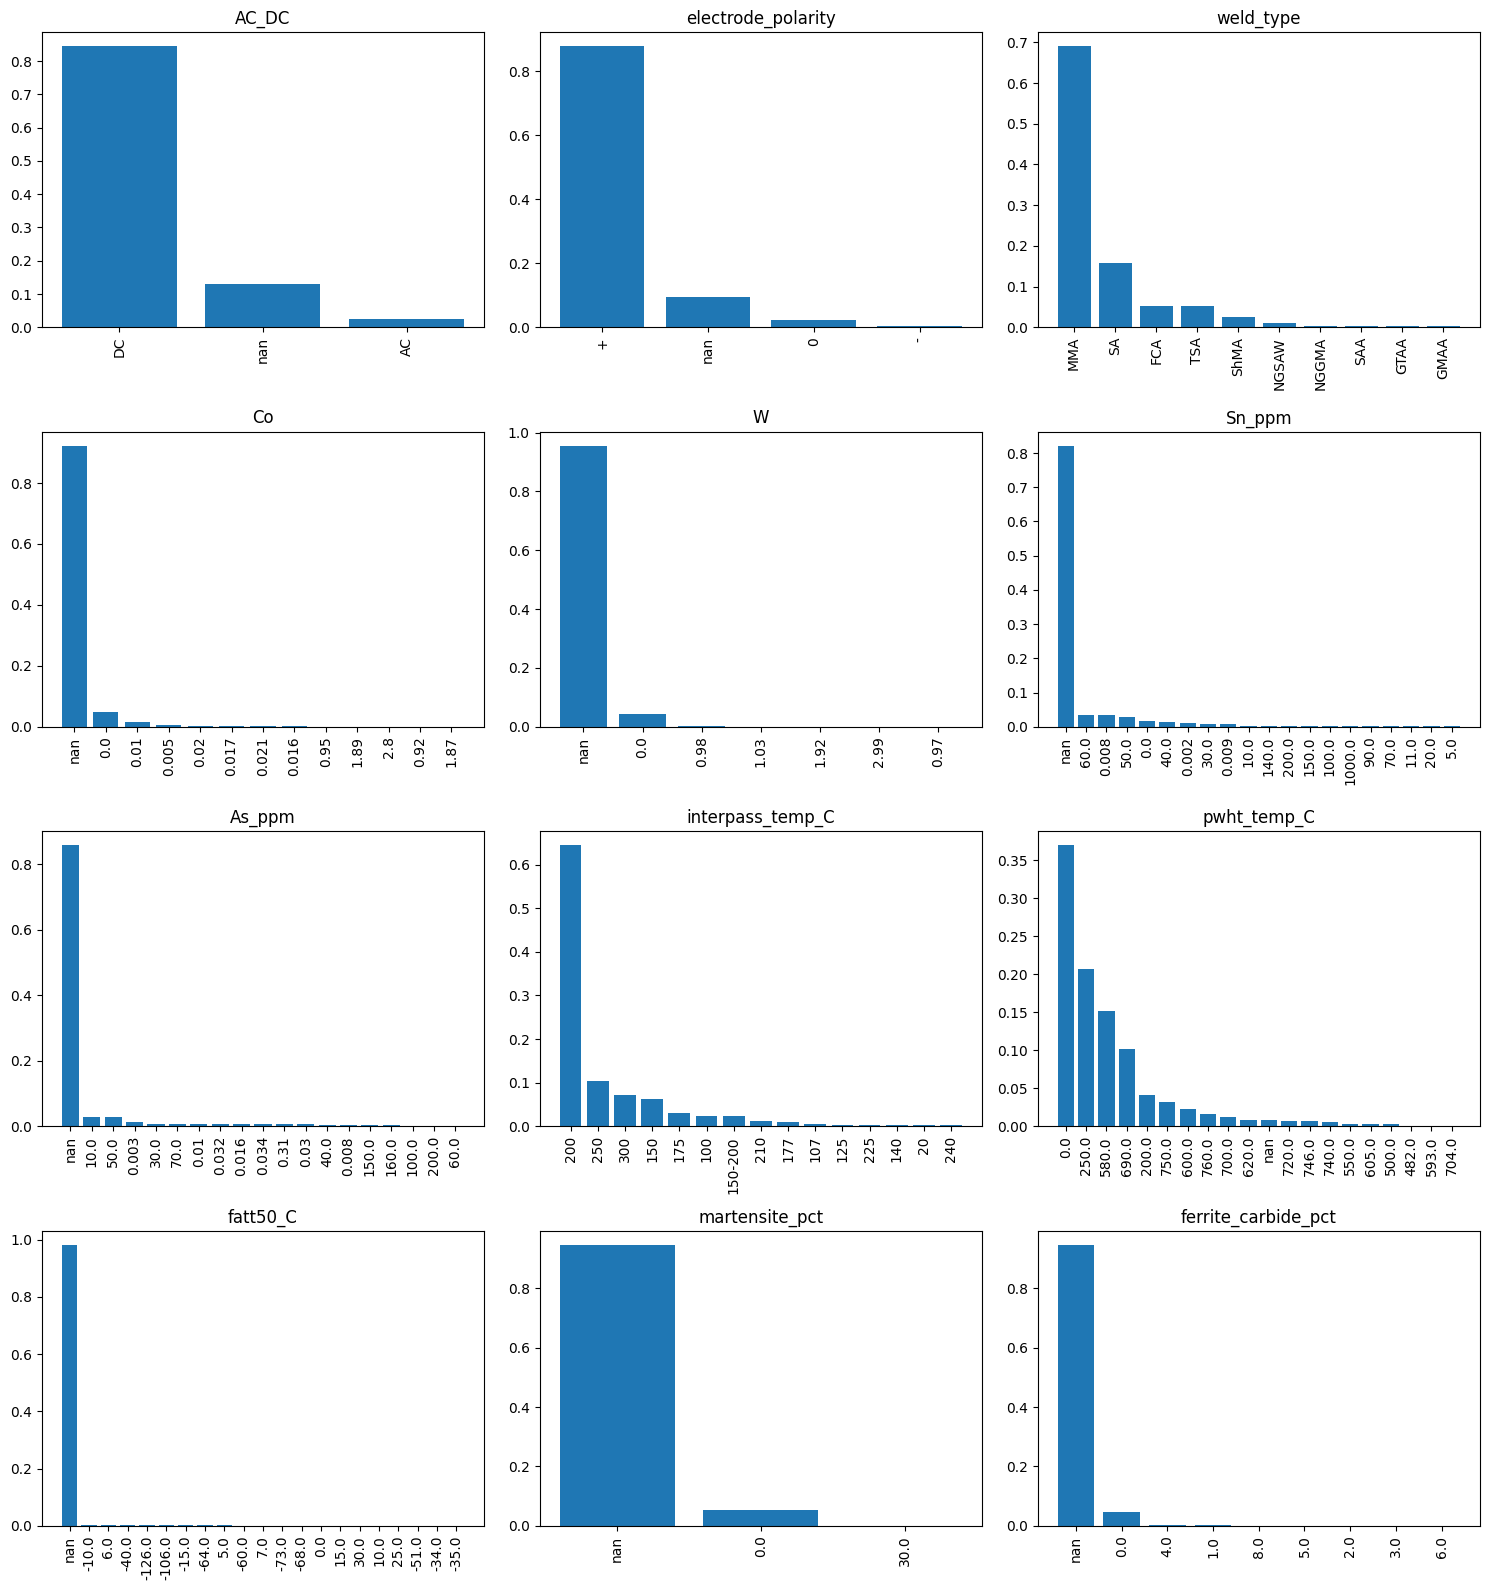

In [17]:
plot_cols = categorical_cols + semi_categorical_cols
n_rows = -(-len(plot_cols) // 3)

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
for ax, col in zip(axes.flat, plot_cols):
    vc = df[col].value_counts(normalize=True, dropna=False)
    vc.index = vc.index.map(str)
    ax.bar(vc.index, vc.values)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=90)
for ax in axes.flat[len(plot_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
df.loc[(df["AC_DC"] == "AC") & (df["electrode_polarity"] == "+"), "electrode_polarity"] = "0"

df["weld_type"] = df["weld_type"].replace({"ShMA": "MMA", "NGSAW": "SA", "NGGMA": "GMAA"})

df["AC_DC"] = df["AC_DC"].map({"DC": 1, "AC": 0}).astype(float)
df["electrode_polarity"] = df["electrode_polarity"].map({"+": 1, "-": -1, "0": 0}).astype(float)
df = pd.get_dummies(df, columns=["weld_type"], dtype=int)

print(df["AC_DC"].value_counts(dropna=False))
print(df["electrode_polarity"].value_counts(dropna=False))
df.filter(like="weld_type_").sum()

AC_DC
1.0    1395
NaN     215
0.0      42
Name: count, dtype: int64
electrode_polarity
 1.0    1447
 NaN     156
 0.0      42
-1.0       7
Name: count, dtype: int64


weld_type_FCA       87
weld_type_GMAA      11
weld_type_GTAA       4
weld_type_MMA     1180
weld_type_SA       279
weld_type_SAA        4
weld_type_TSA       87
dtype: int64

- **AC_DC:** Binary, DC is 1 and AC is 0.

- **electrode_polarity:** Encoded as +1, -1 and 0. A value of 0 is not negative, all 38 rows with 0 are AC welds. With AC the current alternates, so the electrode has no fixed polarity and 0 means "no polarity". Something cannot be AC with a + polarity, so the 4 AC rows marked + are set to 0. The order +1 / 0 / -1 matches the physics, so an ordinal encoding makes sense here.

- **weld_type:** One-hot encoded, as there is no natural order between welding processes. Before that, we merged variants of the same process, using column 28 of `welddb.info`: *"Type of weld; ShMA = MMA = manual metal arc, SA = SMA = submerged arc, FCA = flux cored arc, GTAA gas tungsten arc automatic, GMAA gas metal arc automatic, SAW-NG = submerged arc narrow gap, GMA-NG = gas metal arc narrow gap, ES = electroslag, TSA = tandem submerged arc."*
    - ShMA is treated as equal to MMA, same process.
    - NGSAW is the SAW-NG from the documentation, a narrow gap variant of submerged arc, so it goes into SA.
    - NGGMA is the GMA-NG from the documentation, a narrow gap variant of gas metal arc, so it goes into GMAA.

  NGSAW had 18 rows and NGGMA 7, too few to be useful as their own one-hot column.

In [19]:
df.loc[df["AC_DC"].isna() & (df["electrode_polarity"] == 1), "AC_DC"] = 1

for col in ["AC_DC", "electrode_polarity"]:
    df[col + "_unknown"] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].mode()[0])

df[["AC_DC_unknown", "electrode_polarity_unknown"]].sum()

AC_DC_unknown                 156
electrode_polarity_unknown    156
dtype: int64

- **AC_DC:** A fixed + polarity only exists with DC, so the missing AC_DC values with a + polarity are set to DC. This covers 59 rows.

- **AC_DC, electrode_polarity:** The 156 remaining rows are missing both, the same papers reported neither. They are treated as an "unknown" category through the `_unknown` columns, equal to 1 where the value was missing. The value itself is filled with the mode only so that the column has no NaN, the model can still tell these rows apart through the `_unknown` column.

In [20]:
df = df.drop(columns=["Sn_ppm", "As_ppm", "Sb_ppm", "Co", "W"])
df = df.dropna(subset=["pwht_temp_C", "pwht_time_h"])

print(df.shape)

(1639, 47)


- **Sn_ppm, As_ppm, Sb_ppm, Co, W:** Dropped, between 82% and 95% missing. Imputing would invent most of the column. Filling with 0 would be wrong too, Sn, As and Sb are impurities coming from scrap steel rather than elements added on purpose, so a missing value means "not measured" rather than "not present". `welddb.info` also states that the columns with little data were removed for the original analysis.

- **pwht_temp_C, pwht_time_h:** Only 13 rows are missing, under 1% of the data, so these rows are dropped.

In [21]:
df["interpass_temp_C"] = df["interpass_temp_C"].replace("150-200", "175").astype(float)

df["interpass_temp_C"].value_counts(dropna=False)

interpass_temp_C
200.0    1064
250.0     171
300.0     105
150.0     102
175.0      90
100.0      40
210.0      20
177.0      16
107.0       8
125.0       6
225.0       5
140.0       4
20.0        4
240.0       4
Name: count, dtype: int64

- **interpass_temp_C:** `"150-200"` is a range, not a single temperature, so middle value imputation.

In [22]:
categorical_cols = ["AC_DC", "electrode_polarity", "AC_DC_unknown", "electrode_polarity_unknown"] + [c for c in df.columns if c.startswith("weld_type_")]
id_cols = ["weld_id"]
string_cols = ["N_ppm", "hardness_kg_mm2"]

remaining_cols = [c for c in df.columns if c not in categorical_cols + id_cols + string_cols]
semi_categorical_cols = [c for c in remaining_cols if df[c].nunique() <= 20]
numerical_cols = [c for c in remaining_cols if c not in semi_categorical_cols]

print(len(categorical_cols), len(semi_categorical_cols), len(numerical_cols), len(id_cols), len(string_cols))
print(semi_categorical_cols)

display(df[semi_categorical_cols + numerical_cols].describe())
df.isna().sum()

11 5 28 1 2
['interpass_temp_C', 'pwht_temp_C', 'fatt50_C', 'martensite_pct', 'ferrite_carbide_pct']


,interpass_temp_C,pwht_temp_C,fatt50_C,martensite_pct,ferrite_carbide_pct,C,Si,Mn,S,P,Ni,Cr,Mo,V,Cu,O_ppm,Ti_ppm,Al_ppm,B_ppm,Nb_ppm,current_A,voltage_V,heat_input_kJ_mm,pwht_time_h,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct,charpy_temp_C,charpy_toughness_J,primary_ferrite_pct,ferrite_2nd_phase_pct,acicular_ferrite_pct
count,1639.000000,1639.000000,31.000000,89.000000,89.000000,1639.000000,1639.000000,1639.000000,1635.000000,1629.000000,684.000000,771.000000,780.000000,915.000000,565.000000,1256.000000,923.000000,892.000000,504.000000,739.000000,1391.000000,1391.000000,1639.000000,1639.000000,767.000000,738.000000,687.000000,692.000000,879.000000,879.00000,98.000000,90.000000,90.000000
mean,203.455156,304.674192,-31.096774,0.337079,0.438202,0.075175,0.328603,1.200134,0.009472,0.012836,0.421580,2.135612,0.485303,0.047989,0.173331,441.967357,78.105634,97.875650,5.289683,133.598106,279.846513,27.542602,1.677810,5.049652,506.363233,594.386314,26.315866,72.011416,-34.606371,87.68942,19.153061,25.955556,52.833333
std,38.564872,285.498003,43.644285,3.179994,1.397685,0.023635,0.112800,0.382271,0.011243,0.019614,0.792948,3.040301,0.478745,0.086233,0.326520,147.483825,97.819164,143.437882,10.254195,231.291454,188.732727,12.594240,1.264843,6.096034,91.319972,88.636238,4.862269,8.803713,34.738624,50.11670,11.017654,21.283486,23.483798
min,20.000000,0.000000,-126.000000,0.000000,0.000000,0.029000,0.040000,0.270000,0.001000,0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,115.000000,11.500000,0.600000,0.000000,315.000000,447.000000,10.600000,17.000000,-114.000000,3.00000,0.000000,3.000000,0.000000
25%,200.000000,0.000000,-62.000000,0.000000,0.000000,0.061000,0.270000,0.930000,0.006000,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,370.000000,29.000000,2.000000,2.000000,2.000000,170.000000,21.000000,1.000000,0.000000,443.000000,532.775000,23.000000,68.500000,-60.000000,38.00000,13.000000,9.000000,35.500000
50%,200.000000,250.000000,-15.000000,0.000000,0.000000,0.074000,0.320000,1.250000,0.007000,0.010000,0.067500,0.560000,0.340000,0.003000,0.030000,423.000000,42.000000,37.500000,2.000000,5.000000,170.000000,21.000000,1.000000,2.000000,494.000000,575.500000,26.800000,75.000000,-40.000000,100.00000,19.000000,18.000000,60.000000
75%,200.000000,580.000000,5.000000,0.000000,0.000000,0.084000,0.360000,1.440000,0.010000,0.014000,0.270000,2.300000,1.010000,0.027750,0.190000,471.000000,100.000000,150.000000,2.000000,200.000000,300.000000,30.000000,2.000000,10.000000,555.000000,647.000000,30.000000,78.000000,-17.500000,100.00000,23.750000,38.000000,71.750000
max,300.000000,760.000000,30.000000,30.000000,8.000000,0.180000,1.140000,2.250000,0.140000,0.250000,3.500000,10.200000,1.500000,0.320000,1.630000,1650.000000,690.000000,680.000000,69.000000,1000.000000,900.000000,75.360000,7.900000,24.000000,920.000000,1151.000000,37.000000,83.000000,188.000000,270.00000,48.000000,100.000000,88.000000


C                                0
Si                               0
Mn                               0
S                                4
P                               10
Ni                             955
Cr                             868
Mo                             859
V                              724
Cu                            1074
O_ppm                          383
Ti_ppm                         716
N_ppm                          397
Al_ppm                         747
B_ppm                         1135
Nb_ppm                         900
current_A                      248
voltage_V                      248
AC_DC                            0
electrode_polarity               0
heat_input_kJ_mm                 0
interpass_temp_C                 0
pwht_temp_C                      0
pwht_time_h                      0
yield_strength_MPa             872
uts_MPa                        901
elongation_pct                 952
reduction_area_pct             947
charpy_temp_C       

The column lists are redefined after encoding, with the description and the number of missing values of each column. `string_cols` are the columns still not converted to float, they are kept out of the lists for now.

In [23]:
dropped_cols = [c for c in df.columns if df[c].isna().sum() > 1000]
df = df.drop(columns=dropped_cols)

print(dropped_cols)
display(df.isna().sum())
df.dtypes

['Cu', 'B_ppm', 'hardness_kg_mm2', 'fatt50_C', 'primary_ferrite_pct', 'ferrite_2nd_phase_pct', 'acicular_ferrite_pct', 'martensite_pct', 'ferrite_carbide_pct']


C                               0
Si                              0
Mn                              0
S                               4
P                              10
Ni                            955
Cr                            868
Mo                            859
V                             724
O_ppm                         383
Ti_ppm                        716
N_ppm                         397
Al_ppm                        747
Nb_ppm                        900
current_A                     248
voltage_V                     248
AC_DC                           0
electrode_polarity              0
heat_input_kJ_mm                0
interpass_temp_C                0
pwht_temp_C                     0
pwht_time_h                     0
yield_strength_MPa            872
uts_MPa                       901
elongation_pct                952
reduction_area_pct            947
charpy_temp_C                 760
charpy_toughness_J            760
weld_id                         0
weld_type_FCA 

C                             float64
Si                            float64
Mn                            float64
S                             float64
P                             float64
Ni                            float64
Cr                            float64
Mo                            float64
V                             float64
O_ppm                         float64
Ti_ppm                        float64
N_ppm                             str
Al_ppm                        float64
Nb_ppm                        float64
current_A                     float64
voltage_V                     float64
AC_DC                         float64
electrode_polarity            float64
heat_input_kJ_mm              float64
interpass_temp_C              float64
pwht_temp_C                   float64
pwht_time_h                   float64
yield_strength_MPa            float64
uts_MPa                       float64
elongation_pct                float64
reduction_area_pct            float64
charpy_temp_

Every column with more than 1000 missing values (out of 1639 rows) is dropped, there is too little data to impute from. This removes Cu, B_ppm, hardness_kg_mm2, fatt50_C and the five microstructure columns.

In [24]:
tot = df["N_ppm"].str.extract(r"^(\d+)tot")[0]
df["N_ppm"] = tot.fillna(df["N_ppm"]).astype(float)

for col in ["S", "P", "O_ppm", "N_ppm", "Al_ppm"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["Ni", "Cr", "Mo", "V", "Nb_ppm", "Ti_ppm"]:
    df[col] = df[col].fillna(0)

weld_type = df.filter(like="weld_type_").idxmax(axis=1)
display(df.groupby(weld_type)[["current_A", "voltage_V"]].median())
for col in ["current_A", "voltage_V"]:
    df[col] = df[col].fillna(df.groupby(weld_type)[col].transform("median"))

df.isna().sum()

,current_A,voltage_V
weld_type_FCA,300.0,28.00
weld_type_GMAA,500.0,30.00
weld_type_GTAA,345.0,12.00
weld_type_MMA,170.0,21.00
weld_type_SA,550.0,32.00
weld_type_SAA,400.0,31.50
weld_type_TSA,625.0,72.24


C                               0
Si                              0
Mn                              0
S                               0
P                               0
Ni                              0
Cr                              0
Mo                              0
V                               0
O_ppm                           0
Ti_ppm                          0
N_ppm                           0
Al_ppm                          0
Nb_ppm                          0
current_A                       0
voltage_V                       0
AC_DC                           0
electrode_polarity              0
heat_input_kJ_mm                0
interpass_temp_C                0
pwht_temp_C                     0
pwht_time_h                     0
yield_strength_MPa            872
uts_MPa                       901
elongation_pct                952
reduction_area_pct            947
charpy_temp_C                 760
charpy_toughness_J            760
weld_id                         0
weld_type_FCA 

- **N_ppm:** Values are stored as `"67tot33res"`, representing total and residual nitrogen. We keep only the total nitrogen value (the number before `"tot"`).

- **S, P:** Only 10 rows are missing. Since S and P vary very little, use the median as a close estimate.

- **O_ppm, N_ppm, Al_ppm:** median. Oxygen and nitrogen come from the atmosphere, while aluminium is a deoxidiser, so these elements are expected in every weld; imputing 0 would be inappropriate.

- **Ni, Cr, Mo, V, Nb_ppm, Ti_ppm:** 0 value impute. These are alloying elements deliberately added to steels, so a paper that does not report them most likely studied a weld without those elements. For Ni, Cr, Mo, and V, the 25th percentile of the reported values is already 0; using the median would therefore add alloying elements to otherwise plain steels.

- **current_A, voltage_V:** Imputation using the median **per weld type**. The table above shows that median current and voltage vary substantially between weld types, so using a single global median would be inappropriate for most welds.

- **Targets:** Not imputed `yield_strength_MPa`, `uts_MPa`, `elongation_pct`, `reduction_area_pct`, or `charpy_toughness_J`.

- **charpy_temp_C:** Is not imputed.


In [25]:
df.describe()

,C,Si,Mn,S,P,Ni,Cr,Mo,V,O_ppm,Ti_ppm,N_ppm,Al_ppm,Nb_ppm,current_A,voltage_V,AC_DC,electrode_polarity,heat_input_kJ_mm,interpass_temp_C,pwht_temp_C,pwht_time_h,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct,charpy_temp_C,charpy_toughness_J,weld_type_FCA,weld_type_GMAA,weld_type_GTAA,weld_type_MMA,weld_type_SA,weld_type_SAA,weld_type_TSA,AC_DC_unknown,electrode_polarity_unknown
count,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,767.000000,738.000000,687.000000,692.000000,879.000000,879.00000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000
mean,0.075175,0.328603,1.200134,0.009466,0.012819,0.175937,1.004611,0.230955,0.026790,437.535082,43.985052,103.755339,70.358499,60.237340,271.755034,26.892447,0.974375,0.965833,1.677810,203.455156,304.674192,5.049652,506.363233,594.386314,26.315866,72.011416,-34.606371,87.68942,0.053081,0.006711,0.002441,0.719951,0.162294,0.002441,0.053081,0.095180,0.095180
std,0.023635,0.112800,0.382271,0.011230,0.019555,0.552650,2.341391,0.409610,0.068684,129.344397,82.992133,83.056658,109.983215,168.891178,182.865826,12.040933,0.158063,0.203880,1.264843,38.564872,285.498003,6.096034,91.319972,88.636238,4.862269,8.803713,34.738624,50.11670,0.224264,0.081673,0.049356,0.449160,0.368833,0.049356,0.224264,0.293553,0.293553
min,0.029000,0.040000,0.270000,0.001000,0.002000,0.000000,0.000000,0.000000,0.000000,132.000000,0.000000,21.000000,0.000000,0.000000,115.000000,11.500000,0.000000,-1.000000,0.600000,20.000000,0.000000,0.000000,315.000000,447.000000,10.600000,17.000000,-114.000000,3.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.061000,0.270000,0.930000,0.006000,0.007000,0.000000,0.000000,0.000000,0.000000,397.000000,0.000000,74.000000,30.000000,0.000000,170.000000,21.000000,1.000000,1.000000,1.000000,200.000000,0.000000,0.000000,443.000000,532.775000,23.000000,68.500000,-60.000000,38.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.074000,0.320000,1.250000,0.007000,0.010000,0.000000,0.000000,0.000000,0.000000,423.000000,5.000000,82.000000,37.500000,0.000000,170.000000,21.000000,1.000000,1.000000,1.000000,200.000000,250.000000,2.000000,494.000000,575.500000,26.800000,75.000000,-40.000000,100.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.084000,0.360000,1.440000,0.010000,0.014000,0.030000,0.415000,0.270000,0.010000,453.000000,43.000000,94.000000,50.000000,2.000000,300.000000,30.000000,1.000000,1.000000,2.000000,200.000000,580.000000,10.000000,555.000000,647.000000,30.000000,78.000000,-17.500000,100.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.180000,1.140000,2.250000,0.140000,0.250000,3.500000,10.200000,1.500000,0.320000,1650.000000,690.000000,552.000000,680.000000,1000.000000,900.000000,75.360000,1.000000,1.000000,7.900000,300.000000,760.000000,24.000000,920.000000,1151.000000,37.000000,83.000000,188.000000,270.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
df = df.drop(columns=["electrode_polarity_unknown"])
df.to_csv("../data/welddb_cleaned_missing.csv", index=False)

print(df.shape)

(1639, 37)


- **electrode_polarity_unknown:** Dropped.

- **weld_id:** Kept for now, it is needed later to group rows by source for cross-validation.